Setup

In [115]:
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import matplotlib.animation as animation

In [116]:
# Using these same values everywhere, to keep consistency between plots and animations
EMPTY = 0
WALL = -1
ITEM = 2
ITEM_PICKED = 1.2
START = 2.2
AGENT = 3

CMAP = "GnBu"

Grid layout

In [117]:
# Grid Size
grid_width = 42
grid_height = 42

grid = [[0 for _ in range(grid_width)] for _ in range(grid_height)]

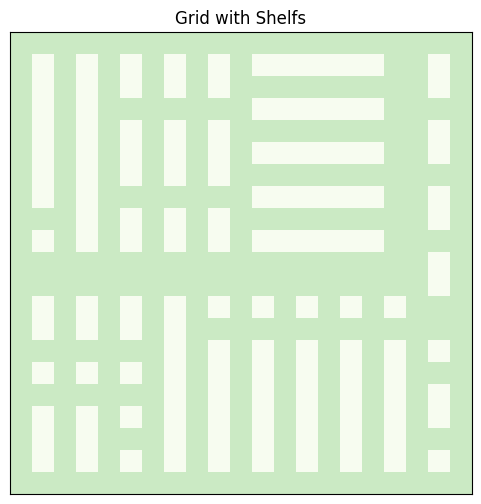

In [118]:
# Function to add a shelf to the grid
def add_shelf(grid, top_left, bottom_right):
    x1, y1 = top_left
    x2, y2 = bottom_right
    
    for y in range(y1, y2):
        for x in range(x1, x2):
            grid[y][x] = 1


# Function where we create our layout with all our shelfs            
def create_store_layout(grid):
    add_shelf(grid, (2, 2), (4, 16))
    add_shelf(grid, (2, 18), (4, 20))
    add_shelf(grid, (6, 2), (8, 20))
    add_shelf(grid, (10, 2), (12, 6))
    add_shelf(grid, (10, 8), (12, 14))
    add_shelf(grid, (10, 16), (12, 20))
    add_shelf(grid, (14, 2), (16, 6))
    add_shelf(grid, (14, 8), (16, 14))
    add_shelf(grid, (14, 16), (16, 20))
    add_shelf(grid, (18, 2), (20, 6))
    add_shelf(grid, (18, 8), (20, 14))
    add_shelf(grid, (18, 16), (20, 20))
    add_shelf(grid, (22, 2), (34, 4))
    add_shelf(grid, (22, 6), (34, 8))
    add_shelf(grid, (22, 10), (34, 12))
    add_shelf(grid, (22, 14), (34, 16))
    add_shelf(grid, (22, 18), (34, 20))
    add_shelf(grid, (38, 2), (40, 6))
    add_shelf(grid, (38, 8), (40, 12))
    add_shelf(grid, (38, 14), (40, 18))
    add_shelf(grid, (38, 20), (40, 24)) 
    add_shelf(grid, (38, 28), (40, 30))
    add_shelf(grid, (38, 32), (40, 36))
    add_shelf(grid, (38, 38), (40, 40))
    add_shelf(grid, (2, 24), (4, 28))
    add_shelf(grid, (2, 30), (4, 32)) 
    add_shelf(grid, (2, 34), (4, 40))
    add_shelf(grid, (6, 24), (8, 28))
    add_shelf(grid, (6, 30), (8, 32)) 
    add_shelf(grid, (6, 34), (8, 40))
    add_shelf(grid, (10, 24), (12, 28))
    add_shelf(grid, (10, 30), (12, 32)) 
    add_shelf(grid, (10, 34), (12, 36))
    add_shelf(grid, (10, 38), (12, 40))
    add_shelf(grid, (14, 24), (16, 40))
    add_shelf(grid, (18, 24), (20, 26))
    add_shelf(grid, (18, 28), (20, 40))
    add_shelf(grid, (22, 24), (24, 26))
    add_shelf(grid, (22, 28), (24, 40))
    add_shelf(grid, (26, 24), (28, 26))
    add_shelf(grid, (26, 28), (28, 40))
    add_shelf(grid, (30, 24), (32, 26))
    add_shelf(grid, (30, 28), (32, 40))
    add_shelf(grid, (34, 24), (36, 26))
    add_shelf(grid, (34, 28), (36, 40))


# Running the function
create_store_layout(grid)


# Function to visualize the grid with shelfs
def visualizeItems_matplotlib(grid):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap = CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Shelfs")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid)

Item/start creation and placement

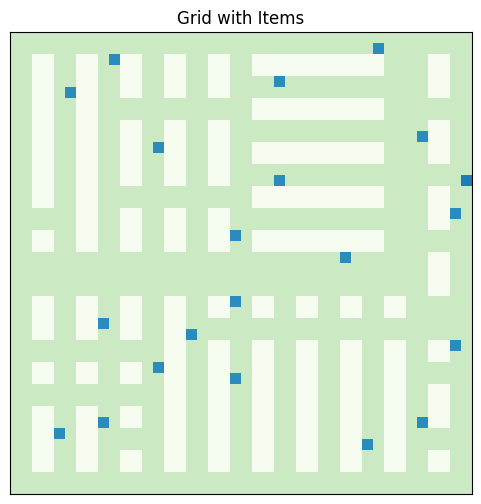

In [119]:
# The agents start position
start = (41, 13)

# Each item location on the grid
items = [
    (13, 10),
    (40, 16),
    (4, 36),
    (13, 30),
    (37, 35),
    (24, 4),
    (5, 5),
    (8, 26),
    (40, 28),
    (24, 13),
    (9, 2),
    (37, 9),
    (30, 20),
    (8, 35),
    (20, 31),
    (20, 24),
    (33, 1),
    (20, 18),
    (32, 37),
    (16, 27)
    
]

items_10 = items[:10]


random.seed(42)

item_sets = {
    5: random.sample(items, 5),
    10: random.sample(items, 10),
    15: random.sample(items, 15),
    20: items.copy()
}


# Function to visualise the grid with shelfs, items, and start position
def visualizeItems_matplotlib(grid, start, items):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    # items
    for (x, y) in items:
        if EMPTY <= x < width and EMPTY <= y < height:
            heat[y][x] = ITEM
    
    # start
    sx, sy = start
    if EMPTY <= sx < width and EMPTY <= sy < height:
        heat[sy][sx] = START
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap=CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Items")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid, start, items)

A* Pathfinding

In [120]:
# ????
def get_neighbors(pos):
    x, y = pos
    
    candidates = [
        (x+1, y),
        (x-1, y),
        (x, y+1),
        (x, y-1)
    ]
    
    valid = []
    for nx, ny in candidates:
        if 0 <= nx < grid_width and 0 <= ny < grid_height:
            valid.append((nx, ny))
    
    return valid

# ????
def heuristic(a, b):
    ax, ay = a
    bx, by = b
    return abs(ax - bx) + abs(ay - by)

In [121]:
# New A*


def astar(grid, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal:
            # reconstruct path
            path = []
            temp = current
            
            while temp in came_from:
                path.append(temp)
                temp = came_from[temp]
            
            path.append(start)
            path.reverse()
            
            distance = g_score[current]
            
            return path, distance
        
        for neighbor in get_neighbors(current):
            x, y = neighbor
            
            # bounds
            if not (0 <= x < len(grid[0]) and 0 <= y < len(grid)):
                continue
            
            # wall
            if grid[y][x] == 1:
                continue
            
            tentative = g_score[current] + 1
            
            if neighbor not in g_score or tentative < g_score[neighbor]:
                g_score[neighbor] = tentative
                came_from[neighbor] = current
                
                f = tentative + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
    
    return [], float("inf")

In [122]:
points = [start] + items
distance_matrix = {}

for i in range(len(points)):
    for j in range(len(points)):
        if i != j:
            
            path, distance = astar(
                grid,
                points[i],
                points[j]
            )
            
            distance_matrix[(i, j)] = distance

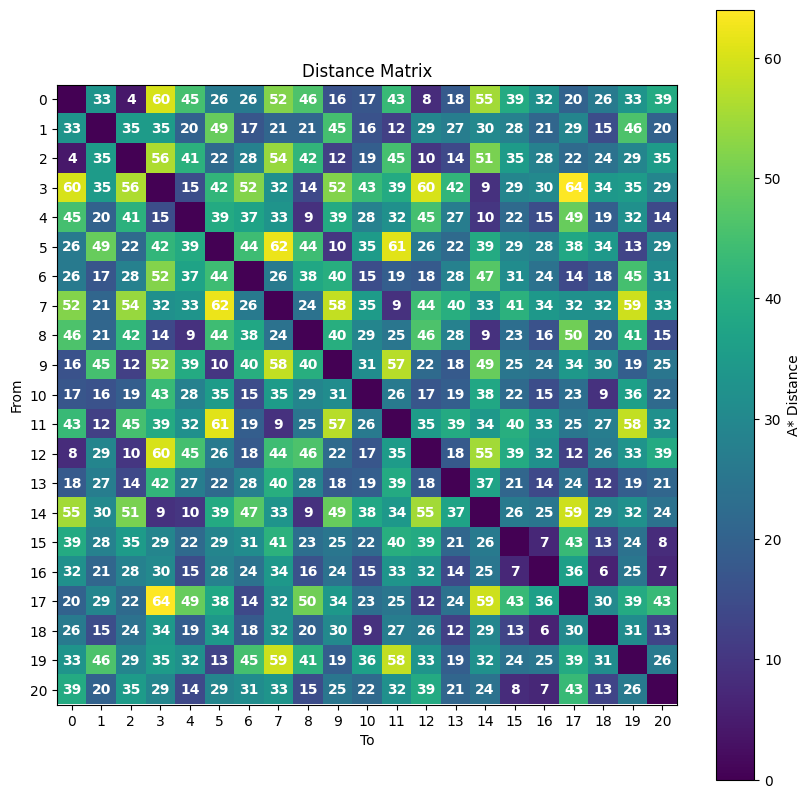

In [123]:
n = len(points)

matrix = np.zeros((n, n))

for (i, j), dist in distance_matrix.items():
    matrix[i][j] = dist

plt.figure(figsize=(10,10))

plt.imshow(matrix)

plt.colorbar(label="A* Distance")

for i in range(n):
    for j in range(n):

        if i != j:

            plt.text(
                j,
                i,
                int(matrix[i][j]),
                ha="center",
                va="center",
                color="white",
                fontsize=10,
                fontweight="bold"
            )

plt.title("Distance Matrix")

plt.xlabel("To")
plt.ylabel("From")

plt.xticks(range(n))
plt.yticks(range(n))

plt.show()

Genetic Algorithm

Godt link til Genetic Algorithms
https://www.tutorialspoint.com/genetic_algorithms/genetic_algorithms_crossover.htm

In [ ]:
#import random - no???
NUM_ITEMS = len(items_10)

In [125]:
def create_population(size):
    population = []
    base = list(range(NUM_ITEMS))
    
    for _ in range(size):
        individual = base[:]
        random.shuffle(individual)
        population.append(individual)
    
    return population

In [126]:
def route_distance(route):
    total = 0
    
    # start → first item
    total += distance_matrix[(0, route[0]+1)]
    
    # between items
    for i in range(len(route)-1):
        total += distance_matrix[(route[i]+1, route[i+1]+1)]
    
    # last item → back to start
    total += distance_matrix[(route[-1]+1, 0)]
    
    return total

In [127]:
# Parent Selection Types: Random, Tournament, Roulette, Rank, SUS

def random_sel(pop): return random.choice(pop)

def tournament_sel(pop):
    return min(random.sample(pop,3), key=route_distance)

def roulette_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    return random.choices(pop,weights=w)[0]

def rank_sel(pop):
    s=sorted(pop,key=route_distance)
    w=list(range(1,len(pop)+1))
    return random.choices(s,weights=w)[0]

def sus_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    total=sum(w)
    pick=random.uniform(0,total)
    cur=0
    for i,p in enumerate(pop):
        cur+=w[i]
        if cur>pick: return p


#Choosing which selection type we want to use
SELECTION="tournament"

def select(pop):
    if SELECTION=="random": return random_sel(pop)
    if SELECTION=="roulette": return roulette_sel(pop)
    if SELECTION=="sus": return sus_sel(pop)
    if SELECTION=="rank": return rank_sel(pop)
    return tournament_sel(pop)

In [128]:
def crossover(p1, p2):
    start, end = sorted(random.sample(range(NUM_ITEMS), 2))
    child = [None]*NUM_ITEMS
    
    child[start:end+1] = p1[start:end+1]
    
    fill = [x for x in p2 if x not in child]
    
    idx = 0
    for i in range(NUM_ITEMS):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    
    return child

In [175]:
def mutate(route, rate=0.01):
    if random.random() < rate:
        i, j = random.sample(range(NUM_ITEMS), 2)
        route[i], route[j] = route[j], route[i]
    return route

In [224]:
# NEW with fitness stuff

def genetic_algorithm_with_history(
    generations=1000,
    size=500,
    mutation=0.1
):

    pop = create_population(size)

    history = []

    # Existing
    distance_history = []

    # New fitness statistics
    fit_best_history = []
    fit_avg_history = []
    fit_worst_history = []

    best = min(pop, key=route_distance)

    for g in range(generations):

        new_pop = []

        for _ in range(size):

            p1 = select(pop)
            p2 = select(pop)

            child = crossover(p1, p2)
            child = mutate(child, mutation)

            new_pop.append(child)

        pop = new_pop

        # Calculate fitness of current population
        population_distances = [
            route_distance(individual)
            for individual in pop
        ]

        current = min(pop, key=route_distance)

        if route_distance(current) < route_distance(best):
            best = current

        # Existing history
        history.append(best.copy())
        distance_history.append(route_distance(best))

        # New statistics
        fit_best_history.append(min(population_distances))
        fit_avg_history.append(
            sum(population_distances) / len(population_distances)
        )
        fit_worst_history.append(max(population_distances))

        if g % 10 == 0:
            print(f"Gen {g}: {route_distance(best)}")

    return (
        best,
        history,
        distance_history,
        fit_best_history,
        fit_avg_history,
        fit_worst_history
    )

In [225]:
best, history_best, distance_history_best, fit_best_history_best, fit_avg_history_best, fit_worst_history_best = genetic_algorithm_with_history(
    generations=200,
    size=100,
    mutation=0.05
)

best_route = history_best[-1]

print("Best route:", best_route)
print("Distance:", route_distance(best_route))

best_opt, history_opt, distance_history_opt, fit_best_history_opt, fit_avg_history_opt, fit_worst_history_opt = genetic_algorithm_with_history(
    generations=50,
    size=100,
    mutation=0.01
)

best_route_optimized = history_opt[-1]

print("Best optimized route:", best_route_optimized)
print("Distance:", route_distance(best_route_optimized))

Gen 0: 250
Gen 10: 228
Gen 20: 228
Gen 30: 228
Gen 40: 220
Gen 50: 212
Gen 60: 212
Gen 70: 210
Gen 80: 210
Gen 90: 210
Gen 100: 210
Gen 110: 210
Gen 120: 210
Gen 130: 210
Gen 140: 204
Gen 150: 204
Gen 160: 204
Gen 170: 204
Gen 180: 204
Gen 190: 204
Best route: [8, 4, 3, 7, 2, 6, 0, 9, 5, 1]
Distance: 204
Gen 0: 250
Gen 10: 198
Gen 20: 198
Gen 30: 198
Gen 40: 198
Best optimized route: [9, 5, 0, 6, 7, 2, 3, 8, 4, 1]
Distance: 198


In [226]:
# Random route

random_route = random.sample(range(NUM_ITEMS), NUM_ITEMS)

print("Random Route Distance:", route_distance(random_route))
print("GA Route Distance - Best:", route_distance(best_route))
print("GA Route Distance - Optimized:", route_distance(best_route_optimized))

route_improvement_best = ((route_distance(best_route)-route_distance(random_route))/route_distance(random_route))*-100
route_improvement_opt = ((route_distance(best_route_optimized)-route_distance(random_route))/route_distance(random_route))*-100

print("Improvement from Best:", route_improvement_best, "%")
print("Improvement from Optimized:", route_improvement_opt, "%")

Random Route Distance: 406
GA Route Distance - Best: 204
GA Route Distance - Optimized: 198
Improvement from Best: 49.75369458128079 %
Improvement from Optimized: 51.231527093596064 %


In [133]:
def benchmark_selection_methods(
    methods,
    generations=100,
    size=100,
    runs=5
):

    results = {}

    convergence_data = {}

    for method in methods:

        global SELECTION
        SELECTION = method

        distances = []
        runtimes = []

        all_histories = []

        print(f"\n===== Testing {method.upper()} =====")

        for r in range(runs):

            start_time = time.time()

            best_route, history, distance_history = genetic_algorithm_with_history(
                generations=generations,
                size=size
            )

            runtime = time.time() - start_time

            best_distance = route_distance(best_route)

            distances.append(best_distance)
            runtimes.append(runtime)

            all_histories.append(distance_history)

            print(
                f"Run {r+1}: "
                f"Distance = {best_distance:.1f}, "
                f"Time = {runtime:.2f}s"
            )

        # ---------- STORE RESULTS ----------
        results[method] = {
            "Average Distance": np.mean(distances),
            "Best Distance": np.min(distances),
            "Average Runtime (s)": np.mean(runtimes)
        }

        # ---------- AVERAGE CONVERGENCE ----------
        convergence_data[method] = np.mean(
            all_histories,
            axis=0
        )

    return results, convergence_data


methods = [
    "random",
    "tournament",
    "roulette",
    "rank",
    "sus"
]

results, convergence_data = benchmark_selection_methods(
    methods,
    generations=100,
    size=100,
    runs=5
)


===== Testing RANDOM =====
Gen 0: 244
Gen 10: 232
Gen 20: 232
Gen 30: 232
Gen 40: 232
Gen 50: 222
Gen 60: 222
Gen 70: 222
Gen 80: 222
Gen 90: 212
Run 1: Distance = 212.0, Time = 0.07s
Gen 0: 252
Gen 10: 236
Gen 20: 234
Gen 30: 218
Gen 40: 218
Gen 50: 218
Gen 60: 216
Gen 70: 216
Gen 80: 216
Gen 90: 216
Run 2: Distance = 216.0, Time = 0.06s
Gen 0: 272
Gen 10: 242
Gen 20: 242
Gen 30: 242
Gen 40: 242
Gen 50: 230
Gen 60: 212
Gen 70: 212
Gen 80: 212
Gen 90: 212
Run 3: Distance = 212.0, Time = 0.06s
Gen 0: 268
Gen 10: 234
Gen 20: 216
Gen 30: 216
Gen 40: 216
Gen 50: 216
Gen 60: 216
Gen 70: 216
Gen 80: 216
Gen 90: 216
Run 4: Distance = 216.0, Time = 0.06s
Gen 0: 242
Gen 10: 218
Gen 20: 218
Gen 30: 216
Gen 40: 216
Gen 50: 216
Gen 60: 216
Gen 70: 216
Gen 80: 216
Gen 90: 216
Run 5: Distance = 216.0, Time = 0.06s

===== Testing TOURNAMENT =====
Gen 0: 260
Gen 10: 188
Gen 20: 188
Gen 30: 188
Gen 40: 188
Gen 50: 188
Gen 60: 188
Gen 70: 188
Gen 80: 188
Gen 90: 186
Run 1: Distance = 186.0, Time = 0.16

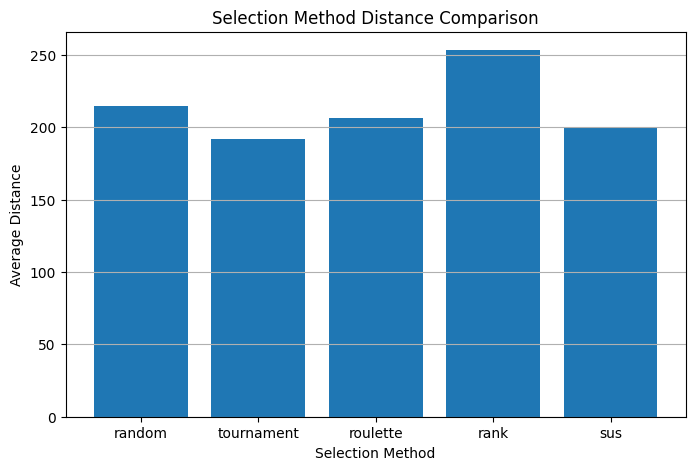

In [134]:
methods = list(results.keys())

avg_distances = [
    results[m]["Average Distance"]
    for m in methods
]

plt.figure(figsize=(8,5))

plt.bar(methods, avg_distances)

plt.ylabel("Average Distance")
plt.xlabel("Selection Method")

plt.title("Selection Method Distance Comparison")

plt.grid(axis='y')

plt.show()

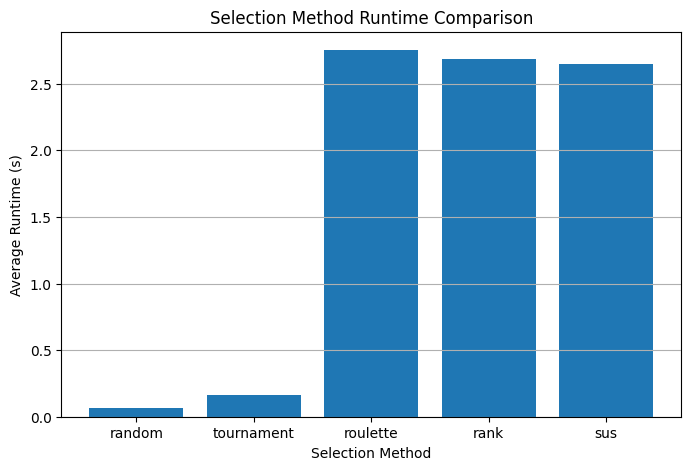

In [135]:
avg_runtimes = [
    results[m]["Average Runtime (s)"]
    for m in methods
]

plt.figure(figsize=(8,5))

plt.bar(methods, avg_runtimes)

plt.ylabel("Average Runtime (s)")
plt.xlabel("Selection Method")

plt.title("Selection Method Runtime Comparison")

plt.grid(axis='y')

plt.show()

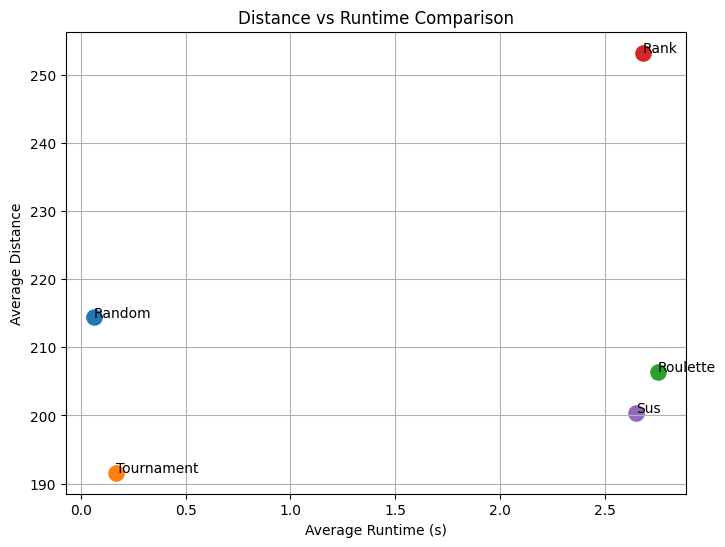

In [136]:
plt.figure(figsize=(8,6))

for method in methods:

    distance = results[method]["Average Distance"]
    runtime = results[method]["Average Runtime (s)"]

    plt.scatter(runtime, distance, s=120)

    plt.text(
        runtime,
        distance,
        method.capitalize(),
        fontsize=10,
        ha='left'
    )

plt.xlabel("Average Runtime (s)")
plt.ylabel("Average Distance")

plt.title("Distance vs Runtime Comparison")

plt.grid(True)

plt.show()

In [137]:
MUTATION_RATE = 0.02

def mutate(route):

    route = route.copy()

    if random.random() < MUTATION_RATE:

        i, j = random.sample(range(NUM_ITEMS), 2)

        route[i], route[j] = route[j], route[i]

    return route

In [138]:
def hyperparameter_analysis():

    population_sizes = [50, 100, 200, 500, 1000]
    mutation_rates = [0.01, 0.02, 0.05, 0.1, 0.2]
    generation_counts = [50, 100, 200, 500, 1000]

    results = []

    global MUTATION_RATE

    # -------------------------------------------------
    # Population Size Analysis
    # -------------------------------------------------

    print("\n===== POPULATION SIZE ANALYSIS =====")

    for pop_size in population_sizes:

        start_time = time.time()

        best_route, history, distance_history = genetic_algorithm_with_history(
            generations=100,
            size=pop_size
        )

        runtime = time.time() - start_time

        distance = route_distance(best_route)

        results.append({
            "Type": "Population Size",
            "Value": pop_size,
            "Distance": distance,
            "Runtime": runtime
        })

        print(f"Population {pop_size}: Distance={distance}, Time={runtime:.2f}s")

    # -------------------------------------------------
    # Mutation Rate Analysis
    # -------------------------------------------------

    print("\n===== MUTATION RATE ANALYSIS =====")

    for rate in mutation_rates:

        MUTATION_RATE = rate

        start_time = time.time()

        best_route, history, distance_history = genetic_algorithm_with_history(
            generations=100,
            size=100
        )

        runtime = time.time() - start_time

        distance = route_distance(best_route)

        results.append({
            "Type": "Mutation Rate",
            "Value": rate,
            "Distance": distance,
            "Runtime": runtime
        })

        print(f"Mutation {rate}: Distance={distance}, Time={runtime:.2f}s")

    # -------------------------------------------------
    # Generation Count Analysis
    # -------------------------------------------------

    print("\n===== GENERATION COUNT ANALYSIS =====")

    for gens in generation_counts:

        start_time = time.time()

        best_route, history, distance_history = genetic_algorithm_with_history(
            generations=gens,
            size=100
        )

        runtime = time.time() - start_time

        distance = route_distance(best_route)

        results.append({
            "Type": "Generations",
            "Value": gens,
            "Distance": distance,
            "Runtime": runtime
        })

        print(f"Generations {gens}: Distance={distance}, Time={runtime:.2f}s")

    return results


hyper_results = hyperparameter_analysis()


===== POPULATION SIZE ANALYSIS =====
Gen 0: 252
Gen 10: 224
Gen 20: 212
Gen 30: 210
Gen 40: 208
Gen 50: 208
Gen 60: 208
Gen 70: 208
Gen 80: 208
Gen 90: 208
Population 50: Distance=208, Time=0.67s
Gen 0: 250
Gen 10: 240
Gen 20: 210
Gen 30: 210
Gen 40: 210
Gen 50: 206
Gen 60: 206
Gen 70: 206
Gen 80: 206
Gen 90: 206
Population 100: Distance=206, Time=2.69s
Gen 0: 222
Gen 10: 222
Gen 20: 210
Gen 30: 210
Gen 40: 210
Gen 50: 208
Gen 60: 208
Gen 70: 208
Gen 80: 208
Gen 90: 208
Population 200: Distance=208, Time=10.67s
Gen 0: 242
Gen 10: 220
Gen 20: 208
Gen 30: 208
Gen 40: 188
Gen 50: 188
Gen 60: 188
Gen 70: 188
Gen 80: 188
Gen 90: 188
Population 500: Distance=188, Time=65.89s
Gen 0: 218
Gen 10: 208
Gen 20: 208
Gen 30: 208
Gen 40: 208
Gen 50: 204
Gen 60: 192
Gen 70: 190
Gen 80: 190
Gen 90: 190
Population 1000: Distance=190, Time=280.90s

===== MUTATION RATE ANALYSIS =====
Gen 0: 276
Gen 10: 234
Gen 20: 208
Gen 30: 208
Gen 40: 208
Gen 50: 208
Gen 60: 208
Gen 70: 208
Gen 80: 208
Gen 90: 208
Mut

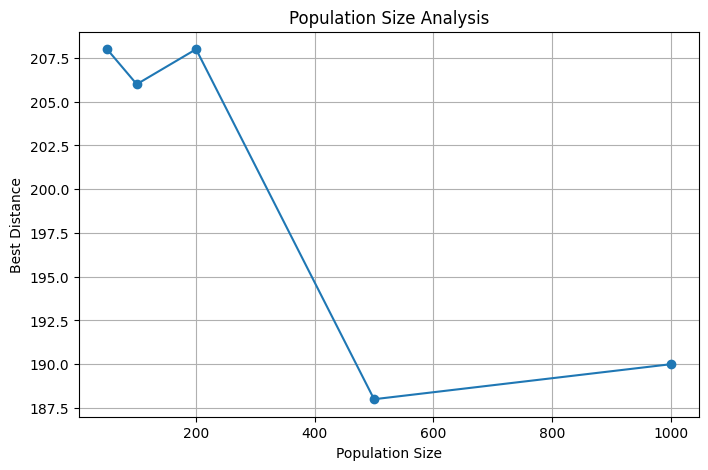

In [139]:
# Population Size

pop_results = [r for r in hyper_results if r["Type"] == "Population Size"]

x = [r["Value"] for r in pop_results]
y = [r["Distance"] for r in pop_results]

plt.figure(figsize=(8,5))

plt.plot(x, y, marker='o')

plt.xlabel("Population Size")
plt.ylabel("Best Distance")

plt.title("Population Size Analysis")

plt.grid(True)

plt.show()

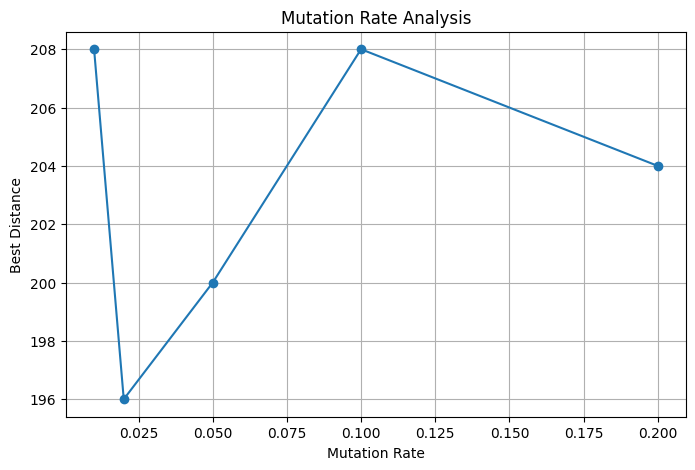

In [140]:
# Mutation Rate

mut_results = [r for r in hyper_results if r["Type"] == "Mutation Rate"]

x = [r["Value"] for r in mut_results]
y = [r["Distance"] for r in mut_results]

plt.figure(figsize=(8,5))

plt.plot(x, y, marker='o')

plt.xlabel("Mutation Rate")
plt.ylabel("Best Distance")

plt.title("Mutation Rate Analysis")

plt.grid(True)

plt.show()

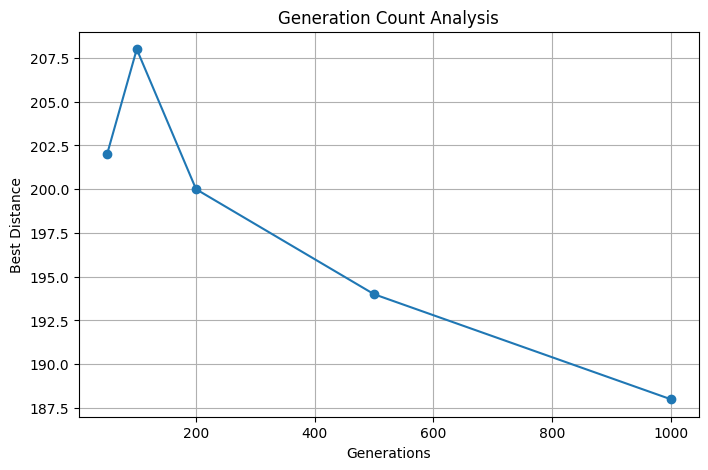

In [141]:
# Generations

gen_results = [r for r in hyper_results if r["Type"] == "Generations"]

x = [r["Value"] for r in gen_results]
y = [r["Distance"] for r in gen_results]

plt.figure(figsize=(8,5))

plt.plot(x, y, marker='o')

plt.xlabel("Generations")
plt.ylabel("Best Distance")

plt.title("Generation Count Analysis")

plt.grid(True)

plt.show()

In [163]:
def parameter_grid_search():

    population_sizes = [50, 100, 200]
    mutation_rates = [0.01, 0.02, 0.05]
    generation_counts = [50, 100, 200]

    results = []

    global MUTATION_RATE

    for pop_size in population_sizes:
        for mut_rate in mutation_rates:
            for gens in generation_counts:

                MUTATION_RATE = mut_rate

                start_time = time.time()

                best_route, history, distance_history = (
                    genetic_algorithm_with_history(
                        generations=gens,
                        size=pop_size
                    )
                )

                runtime = time.time() - start_time

                distance = route_distance(best_route)

                results.append({
                    "Population": pop_size,
                    "Mutation": mut_rate,
                    "Generations": gens,
                    "Distance": distance,
                    "Runtime": runtime
                })

                print(
                    f"Pop={pop_size}, "
                    f"Mut={mut_rate}, "
                    f"Gen={gens} "
                    f"-> Distance={distance}"
                )

    return results

grid_results = parameter_grid_search()

Gen 0: 260
Gen 10: 216
Gen 20: 216
Gen 30: 216
Gen 40: 216
Pop=50, Mut=0.01, Gen=50 -> Distance=216
Gen 0: 268
Gen 10: 242
Gen 20: 230
Gen 30: 230
Gen 40: 230
Gen 50: 230
Gen 60: 230
Gen 70: 230
Gen 80: 230
Gen 90: 230
Pop=50, Mut=0.01, Gen=100 -> Distance=230
Gen 0: 272
Gen 10: 224
Gen 20: 224
Gen 30: 224
Gen 40: 224
Gen 50: 206
Gen 60: 206
Gen 70: 206
Gen 80: 206
Gen 90: 206
Gen 100: 206
Gen 110: 206
Gen 120: 206
Gen 130: 206
Gen 140: 206
Gen 150: 202
Gen 160: 202
Gen 170: 202
Gen 180: 202
Gen 190: 202
Pop=50, Mut=0.01, Gen=200 -> Distance=202
Gen 0: 242
Gen 10: 210
Gen 20: 210
Gen 30: 210
Gen 40: 210
Pop=50, Mut=0.02, Gen=50 -> Distance=210
Gen 0: 262
Gen 10: 228
Gen 20: 228
Gen 30: 228
Gen 40: 228
Gen 50: 226
Gen 60: 216
Gen 70: 216
Gen 80: 216
Gen 90: 216
Pop=50, Mut=0.02, Gen=100 -> Distance=216
Gen 0: 270
Gen 10: 236
Gen 20: 236
Gen 30: 236
Gen 40: 230
Gen 50: 202
Gen 60: 202
Gen 70: 202
Gen 80: 202
Gen 90: 202
Gen 100: 202
Gen 110: 202
Gen 120: 202
Gen 130: 202
Gen 140: 202
Gen

In [227]:
best_hyperparameter_result = min(
    grid_results,
    key=lambda x: x["Distance"]
)

optimized_hyperparameter_result = min(
    grid_results,
    key=lambda x: x["Distance"] + 10*x["Runtime"]
)


print("Best Hyperparameter Combination:")
print(best_hyperparameter_result)

print("Optimized Hyperparameter Combination:")
print(optimized_hyperparameter_result)

Best Hyperparameter Combination:
{'Population': 100, 'Mutation': 0.05, 'Generations': 200, 'Distance': 188, 'Runtime': 6.630021095275879}
Optimized Hyperparameter Combination:
{'Population': 100, 'Mutation': 0.01, 'Generations': 50, 'Distance': 196, 'Runtime': 1.3385934829711914}


In [142]:
def scalability_analysis():

    item_counts = [5, 10, 15, 20]

    results = []

    for count in item_counts:

        current_items = item_sets[count]

        current_points = [start] + current_items

        # -----------------------------
        # Build Distance Matrix
        # -----------------------------

        current_distance_matrix = {}

        for i in range(len(current_points)):
            for j in range(len(current_points)):

                if i != j:

                    _, dist = astar(
                        grid,
                        current_points[i],
                        current_points[j]
                    )

                    current_distance_matrix[(i, j)] = dist

        # -----------------------------
        # Temporary Globals
        # -----------------------------

        global NUM_ITEMS
        global distance_matrix

        old_num = NUM_ITEMS
        old_matrix = distance_matrix

        NUM_ITEMS = count
        distance_matrix = current_distance_matrix

        # -----------------------------
        # Run GA
        # -----------------------------

        start_time = time.time()

        best_route, history, distance_history = genetic_algorithm_with_history(
            generations=100,
            size=100
        )

        runtime = time.time() - start_time

        distance = route_distance(best_route)

        results.append({
            "Items": count,
            "Distance": distance,
            "Runtime": runtime
        })

        print(f"{count} Items: Distance={distance}, Time={runtime:.2f}s")

        # restore
        NUM_ITEMS = old_num
        distance_matrix = old_matrix

    return results


scale_results = scalability_analysis()

Gen 0: 134
Gen 10: 134
Gen 20: 134
Gen 30: 134
Gen 40: 134
Gen 50: 134
Gen 60: 134
Gen 70: 134
Gen 80: 134
Gen 90: 134
5 Items: Distance=134, Time=1.77s
Gen 0: 238
Gen 10: 210
Gen 20: 204
Gen 30: 198
Gen 40: 198
Gen 50: 198
Gen 60: 198
Gen 70: 198
Gen 80: 198
Gen 90: 198
10 Items: Distance=198, Time=2.95s
Gen 0: 340
Gen 10: 340
Gen 20: 340
Gen 30: 340
Gen 40: 328
Gen 50: 328
Gen 60: 312
Gen 70: 308
Gen 80: 308
Gen 90: 308
15 Items: Distance=308, Time=4.18s
Gen 0: 478
Gen 10: 450
Gen 20: 450
Gen 30: 450
Gen 40: 450
Gen 50: 420
Gen 60: 420
Gen 70: 420
Gen 80: 420
Gen 90: 420
20 Items: Distance=420, Time=5.51s


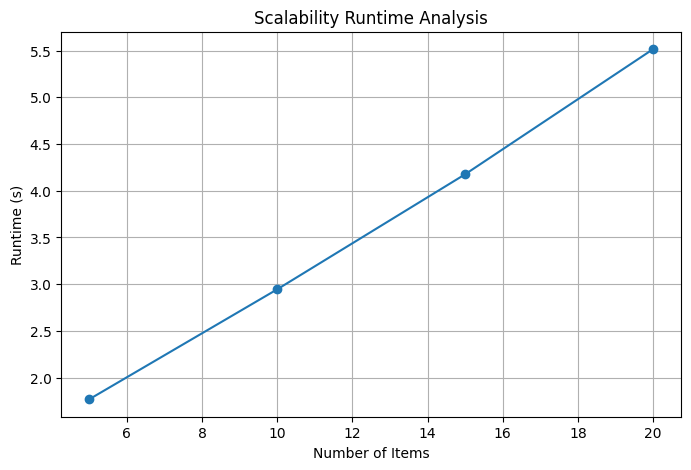

In [143]:
x = [r["Items"] for r in scale_results]
y = [r["Runtime"] for r in scale_results]

plt.figure(figsize=(8,5))

plt.plot(x, y, marker='o')

plt.xlabel("Number of Items")
plt.ylabel("Runtime (s)")

plt.title("Scalability Runtime Analysis")

plt.grid(True)

plt.show()

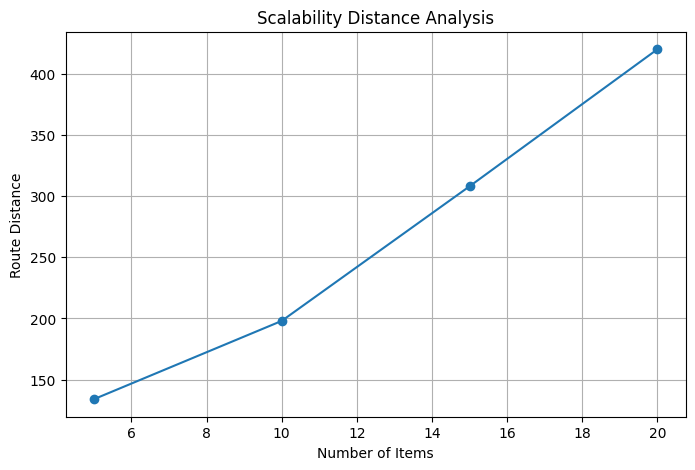

In [144]:
x = [r["Items"] for r in scale_results]
y = [r["Distance"] for r in scale_results]

plt.figure(figsize=(8,5))

plt.plot(x, y, marker='o')

plt.xlabel("Number of Items")
plt.ylabel("Route Distance")

plt.title("Scalability Distance Analysis")

plt.grid(True)

plt.show()

In [ ]:
# NEW

def build_full_path(route):

    full_path = []

    current = start

    for idx in route:

        target = items[idx]

        # unified A*
        path_segment, _ = astar(
            grid,
            current,
            target
        )

        # unreachable
        if not path_segment:
            print(f"No path from {current} to {target}")
            return []

        # avoid duplicates
        if full_path:
            path_segment = path_segment[1:]

        full_path.extend(path_segment)

        current = target

    # return to start
    path_back, _ = astar(
        grid,
        current,
        start
    )

    if path_back:
        full_path.extend(path_back[1:])

    return full_path

full_path = build_full_path(best_route)
optimized_full_path = build_full_path(best_route_optimized)
random_full_path = build_full_path(random_route)

In [146]:
%matplotlib inline

In [191]:
# NEW

def visualizeItems_matplotlib(
    grid,
    full_path,
    start,
    items,
    route
):
    plt.close('all')

    height = len(grid)
    width = len(grid[0])

    heat = np.full(
        (height, width),
        EMPTY,
        dtype=float
    )

    # shelves
    for y in range(height):
        for x in range(width):

            if grid[y][x] == 1:
                heat[y][x] = WALL

    # items
    for (x, y) in items:

        if 0 <= x < width and 0 <= y < height:
            heat[y][x] = ITEM

    # start
    sx, sy = start

    if 0 <= sx < width and 0 <= sy < height:
        heat[sy][sx] = START

    # path
    for (x, y) in full_path:

        if 0 <= x < width and 0 <= y < height:

            if (x, y) != start and (x, y) not in items:
                heat[y][x] = AGENT

    # ---------- PLOT ----------
    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3
    )

    # order numbers
    for order, item_idx in enumerate(route):

        x, y = items[item_idx]

        ax.text(
            x,
            y,
            str(order + 1),
            color="white",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

    ax.set_title("Optimized Picking Route")

    ax.set_xticks([])
    ax.set_yticks([])

    fig.show()


C:\Users\clama\AppData\Local\Temp\ipykernel_42088\4274520749.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


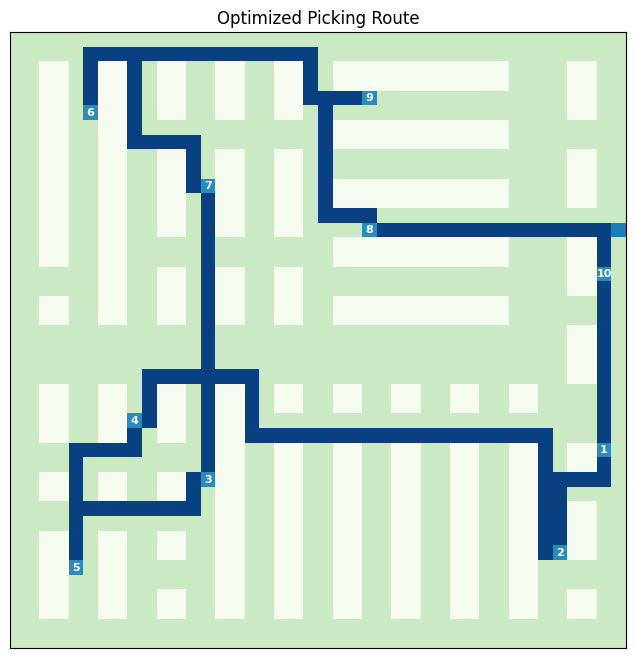

In [228]:
visualizeItems_matplotlib(grid, full_path, start, items_10, best_route)

C:\Users\clama\AppData\Local\Temp\ipykernel_42088\4274520749.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


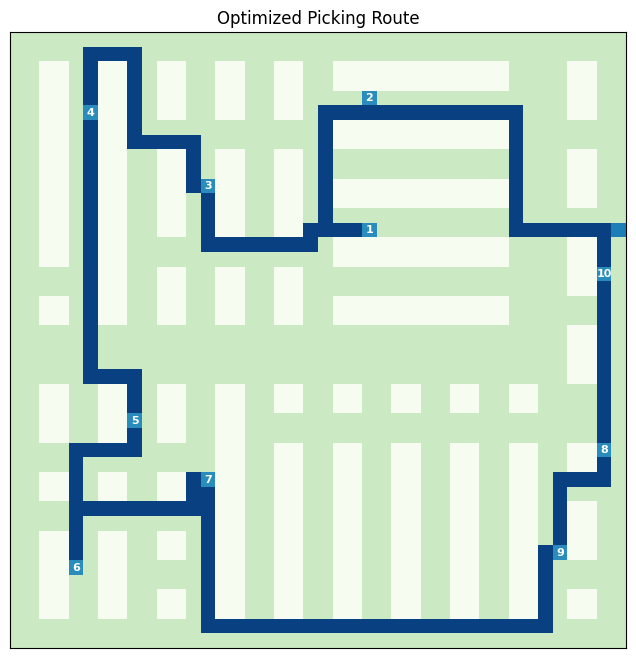

In [229]:
visualizeItems_matplotlib(grid, optimized_full_path, start, items_10, best_route_optimized)

C:\Users\clama\AppData\Local\Temp\ipykernel_42088\4274520749.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


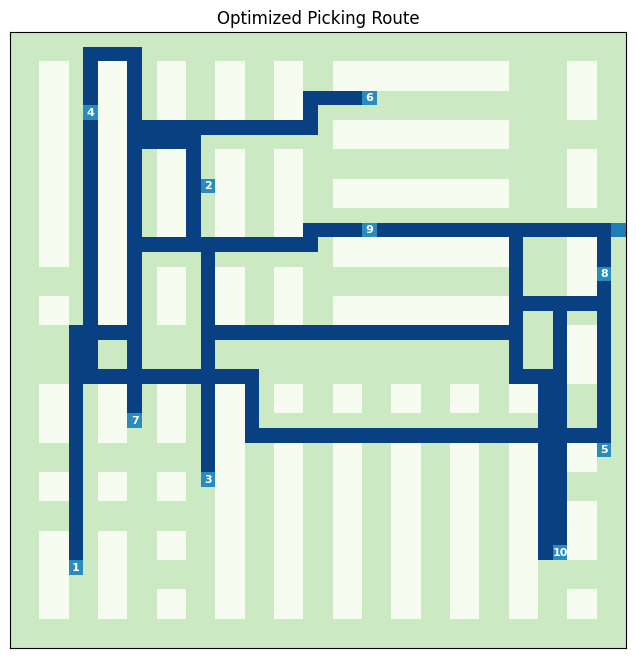

In [230]:
visualizeItems_matplotlib(grid, random_full_path, start, items_10, random_route)

In [231]:
# NEW

def animate_heatmap_funcanimation(
    grid,
    path,
    start,
    items,
    trail_length=10,
    interval=50
):

    height = len(grid)
    width = len(grid[0])

    item_set = set(items)

    # ---------- STATIC BASE ----------
    base_heat = np.full((height, width), EMPTY, dtype=float)

    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                base_heat[y][x] = WALL

    # ---------- FIGURE ----------
    fig, ax = plt.subplots(figsize=(6,6))

    heat = base_heat.copy()

    img = ax.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3,
        animated=True
    )

    ax.set_xticks([])
    ax.set_yticks([])

    # ---------- UPDATE FUNCTION ----------
    def update(frame):

        current = path[frame]

        # reset frame
        heat = base_heat.copy()

        # ---------- TRAIL ----------
        start_idx = max(0, frame - trail_length)

        trail = path[start_idx:frame+1]

        for i, (x, y) in enumerate(trail):

            intensity = (i + 1) / len(trail)

            heat[y][x] = 0.2 + intensity * 1.8

        # ---------- VISITED ITEMS ----------
        visited_items = set(path[:frame+1]) & item_set

        for (x, y) in items:

            if (x, y) in visited_items:
                heat[y][x] = ITEM_PICKED
            else:
                heat[y][x] = ITEM

        # ---------- AGENT ----------
        x, y = current
        heat[y][x] = AGENT

        # ---------- START ----------
        sx, sy = start
        heat[sy][sx] = START

        # ---------- UPDATE IMAGE ----------
        img.set_array(heat)

        ax.set_title(
            f"Step {frame+1}/{len(path)} | "
            f"Collected: {len(visited_items)}/{len(items)}"
        )

        return [img]

    # ---------- CREATE ANIMATION ----------
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(path),
        interval=interval,
        blit=False,
        repeat=False
    )

    return ani

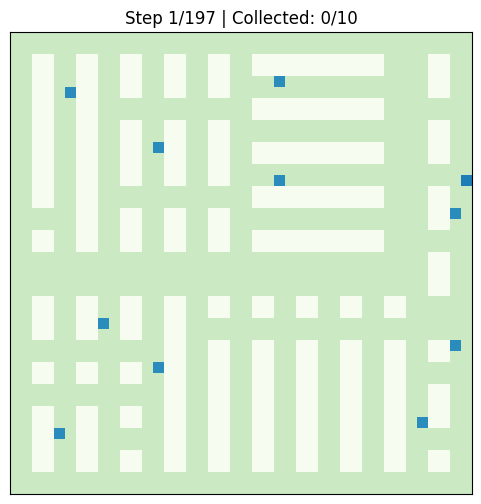

In [195]:
from IPython.display import HTML

ani = animate_heatmap_funcanimation(
    grid,
    optimized_full_path,
    start,
    items_10
)

HTML(ani.to_jshtml())

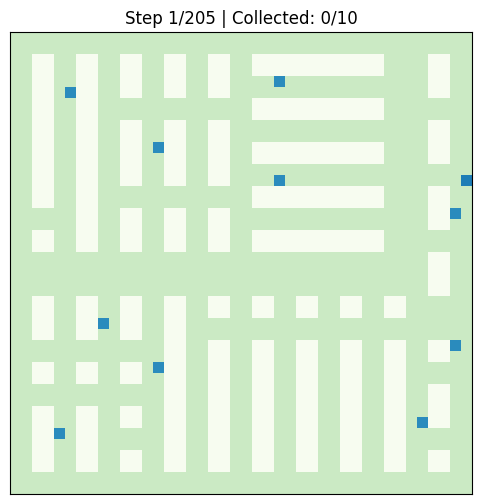

In [196]:
from IPython.display import HTML

ani = animate_heatmap_funcanimation(
    grid,
    full_path,
    start,
    items_10
)

HTML(ani.to_jshtml())

In [ ]:
# Animation of the GA evolution

def animate_ga_evolution(
    grid,
    history,
    distance_history,
    start,
    items,
    interval=150,
    generation_step=5
):

    height = len(grid)
    width = len(grid[0])

    # ---------- GENERATIONS TO SHOW ----------
    shown_generations = list(
        range(0, len(history), generation_step)
    )

    # ---------- STATIC BASE ----------
    base_heat = np.full((height, width), EMPTY, dtype=float)

    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                base_heat[y][x] = WALL

    # ---------- FIGURE ----------
    fig = plt.figure(figsize=(12,6))

    # LEFT = warehouse
    ax_grid = fig.add_subplot(1, 2, 1)

    # RIGHT = convergence graph
    ax_graph = fig.add_subplot(1, 2, 2)

    heat = base_heat.copy()

    img = ax_grid.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3,
        animated=True
    )

    ax_grid.set_xticks([])
    ax_grid.set_yticks([])

    # ---------- GRAPH SETUP ----------
    ax_graph.set_title("GA Convergence")

    ax_graph.set_xlabel("Generation")
    ax_graph.set_ylabel("Distance")

    ax_graph.set_xlim(0, len(history))

    ax_graph.set_ylim(
        min(distance_history) * 0.95,
        max(distance_history) * 1.05
    )

    line, = ax_graph.plot([], [])

    # ---------- UPDATE FUNCTION ----------
    def update(frame_idx):

        gen = shown_generations[frame_idx]

        route = history[gen]

        heat = base_heat.copy()

        # ---------- BUILD PATH ----------
        full_path = build_full_path(route)

        # ---------- GENERATION COLOR ----------
        generation_progress = gen / len(history)

        # path intensity evolves over generations
        path_value = 0.5 + generation_progress * 2.0

        # ---------- DRAW PATH ----------
        for (x, y) in full_path:

            if (x, y) != start and (x, y) not in items:
                heat[y][x] = path_value

        # ---------- ITEMS ----------
        for item in items:

            x, y = item

            heat[y][x] = ITEM

        # ---------- START ----------
        sx, sy = start
        heat[sy][sx] = START

        # ---------- UPDATE GRID ----------
        img.set_array(heat)

        # ---------- REMOVE OLD TEXT ----------
        for txt in ax_grid.texts:
            txt.remove()

        # ---------- DRAW ORDER NUMBERS ----------
        for order, item_idx in enumerate(route):

            x, y = items[item_idx]

            ax_grid.text(
                x,
                y,
                str(order + 1),
                color="white",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold"
            )

        # ---------- GRID TITLE ----------
        ax_grid.set_title(
            f"Generation {gen+1}/{len(history)}\n"
            f"Distance: {route_distance(route)}"
        )

        # ---------- UPDATE GRAPH ----------
        x_data = list(range(gen + 1))
        y_data = distance_history[:gen + 1]

        line.set_data(x_data, y_data)

        return [img, line]

    # ---------- CREATE ANIMATION ----------
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(shown_generations),
        interval=interval,
        blit=False,
        repeat=False
    )

    return ani

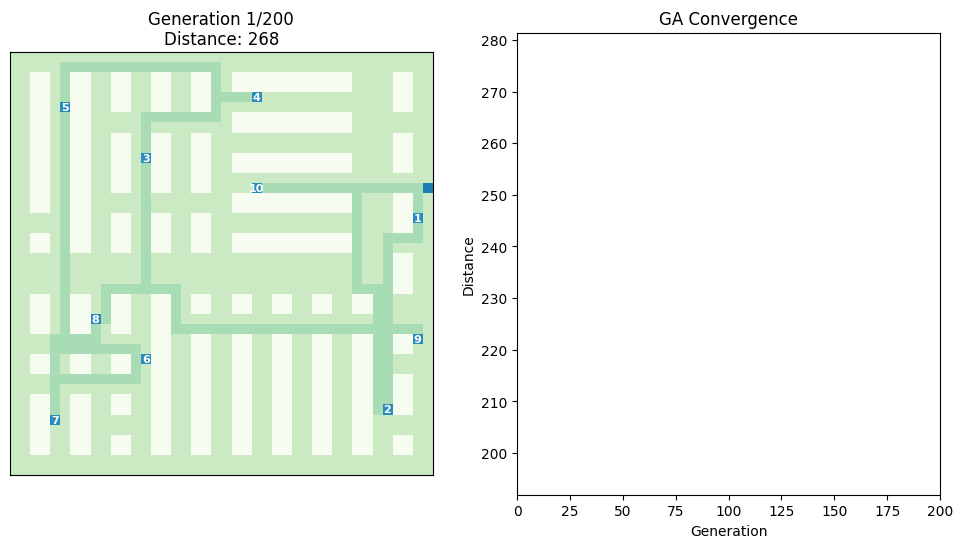

In [201]:
ani = animate_ga_evolution(
    grid,
    history_best,
    distance_history_best,
    start,
    items_10,
    interval=150,
    generation_step=5
)

HTML(ani.to_jshtml())

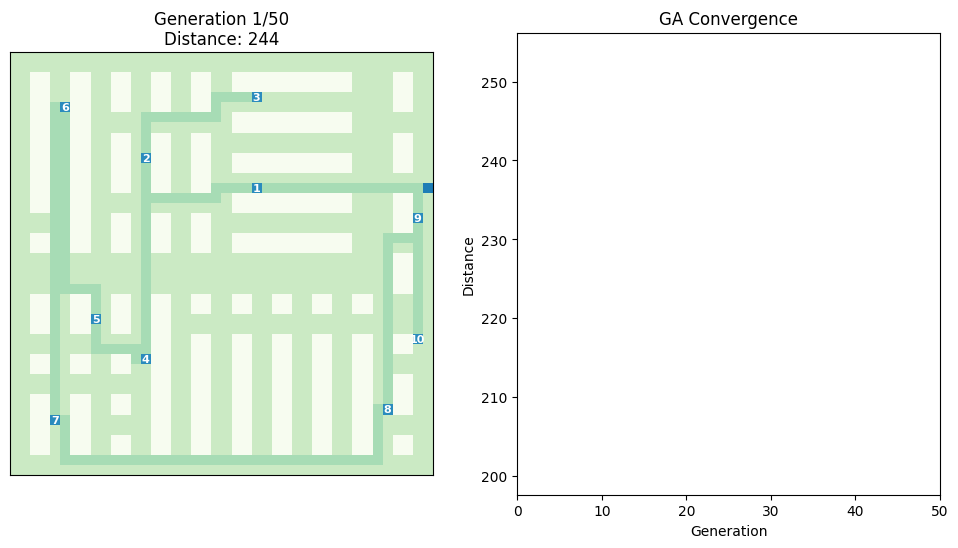

In [202]:
ani = animate_ga_evolution(
    grid,
    history_opt,
    distance_history_opt,
    start,
    items_10,
    interval=150,
    generation_step=5
)

HTML(ani.to_jshtml())

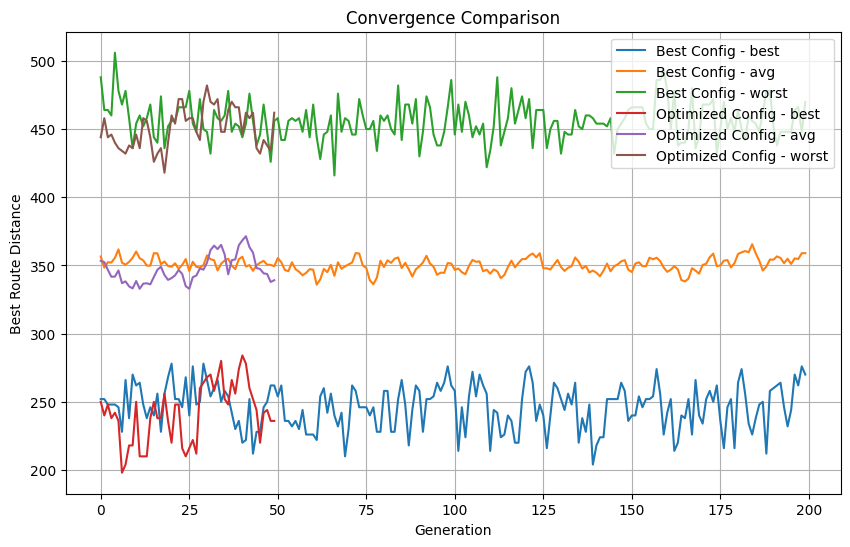

In [232]:
plt.figure(figsize=(10,6))

plt.plot(
    fit_best_history_best,
    label="Best Config - best"
)

plt.plot(
    fit_avg_history_best,
    label="Best Config - avg"
)

plt.plot(
    fit_worst_history_best,
    label="Best Config - worst"
)

plt.plot(
    fit_best_history_opt,
    label="Optimized Config - best"
)

plt.plot(
    fit_avg_history_opt,
    label="Optimized Config - avg"
)

plt.plot(
    fit_worst_history_opt,
    label="Optimized Config - worst"
)

plt.xlabel("Generation")
plt.ylabel("Best Route Distance")

plt.title("Convergence Comparison")

plt.legend()

plt.grid(True)

plt.show()